In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
from src.misc.metrics import *

result_folder = "results/H100_r2/llama3.2-vision_11b-functionary-small"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

{'task_completion_rate': 1,
 'task_success_rate': 0.06666666666666667,
 'total_execution_time': 7379.050798,
 'mean_execution_time': 3.7267933323232323,
 'total_tasks': 1980,
 'DB_QUERY_TOOL_NOT_INITIALIZED': 1437,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 323,
 'SUCCESS': 132,
 'OCR_TOOL_ARGS_MISMATCH': 71,
 'DB_QUERY_TOOL_ARGS_MISMATCH': 14,
 'DB_UPDATE_TOOL_ARGS_MISMATCH': 3}

In [5]:
!python src/misc/status.py {result_folder}

Calculating metrics for results/H100_r2/llama3.2-vision_11b-functionary-small/emails.db...

Full metrics:
	task_completion_rate: 1
	task_success_rate: 0.06666666666666667
	total_execution_time: 7379.050798
	mean_execution_time: 3.7267933323232323
	total_tasks: 1980
	DB_QUERY_TOOL_NOT_INITIALIZED: 1437
	DB_UPDATE_TOOL_NOT_INITIALIZED: 323
	SUCCESS: 132
	OCR_TOOL_ARGS_MISMATCH: 71
	DB_QUERY_TOOL_ARGS_MISMATCH: 14
	DB_UPDATE_TOOL_ARGS_MISMATCH: 3

Vision metrtics:
	task_completion_rate: 1
	task_success_rate: 0.07272727272727272
	total_execution_time: 3128.145465
	mean_execution_time: 3.159742893939394
	total_tasks: 990
	DB_QUERY_TOOL_NOT_INITIALIZED: 615
	DB_UPDATE_TOOL_NOT_INITIALIZED: 220
	SUCCESS: 72
	OCR_TOOL_ARGS_MISMATCH: 71
	DB_QUERY_TOOL_ARGS_MISMATCH: 10
	DB_UPDATE_TOOL_ARGS_MISMATCH: 2

Non-vision metrtics:
	task_completion_rate: 1
	task_success_rate: 0.06060606060606061
	total_execution_time: 4250.905333
	mean_execution_time: 4.2938437707070705
	total_tasks: 990
	DB_QUERY_TOOL_

In [6]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,full_logs,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,DB_QUERY_TOOL_NOT_INITIALIZED,"To begin the reconciliation process, I need to...",2025-04-13 17:06:35.967091,2025-04-13 17:06:47.492673,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",11.5256,3,863,727,136,0.0,SUCCESS,11.525582,0 days 00:00:11
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,DB_QUERY_TOOL_NOT_INITIALIZED,I will process the invoice data provided. Sinc...,2025-04-13 17:06:47.500656,2025-04-13 17:06:49.639376,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",2.1387,3,856,729,127,0.0,SUCCESS,2.138720,0 days 00:00:02
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,DB_UPDATE_TOOL_NOT_INITIALIZED,"To proceed with the invoice reconciliation, I ...",2025-04-13 17:06:49.645506,2025-04-13 17:06:52.291184,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",2.6457,5,1633,1449,184,0.0,SUCCESS,2.645678,0 days 00:00:02
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-13 17:06:52.296869,2025-04-13 17:06:58.488971,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",6.1921,10,4886,4233,653,0.0,SUCCESS,6.192102,0 days 00:00:06
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,DB_UPDATE_TOOL_NOT_INITIALIZED,ERROR: The information provided does not conta...,2025-04-13 17:06:58.494156,2025-04-13 17:07:01.527208,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",3.0331,7,2524,2299,225,0.0,ERROR,3.033052,0 days 00:00:03


In [7]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

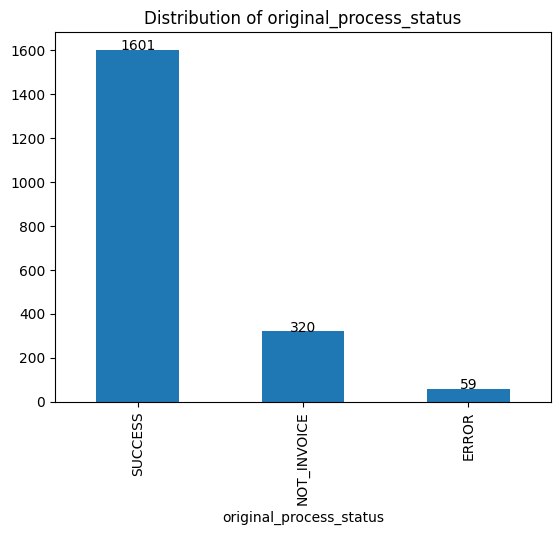

In [8]:
plot_value_distribution(df, "original_process_status")

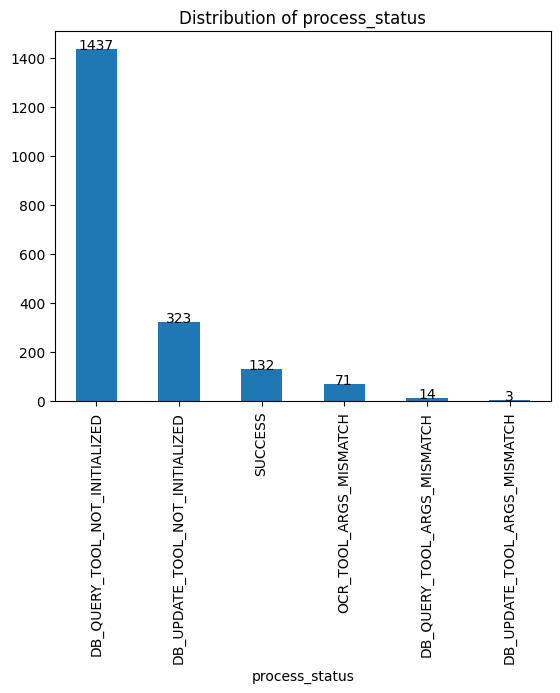

In [9]:
plot_value_distribution(df, "process_status")

In [10]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: DB_QUERY_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: To begin the reconciliation process, I need to first check if the Invoice ID (43925) exists in our transaction database. I will also compare the amount mentioned in the email ($196) with the amount recorded in the dat

In [11]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

4

In [12]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-13T17:06:35.967091",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-13T17:06:45.698030",


In [13]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'To begin the reconciliation process, I need to first check if the Invoice ID (43925) exists in our transaction database. I will also compare the amount mentioned in the email ($196) with the amount recorded in the database.\n\nLet me proceed with this task and provide you with the necessary information once I have completed it.',
 'timestamp': '2025-04-13T17:06:47.492601',
 'usage': {'input_tokens': 350,
  'output_tokens': 66,
  'total_tokens': 416,
  'input_token_details': {},
  'output_token_details': {}},
 'model_name': 'functionary-small',
 'additional_kwargs': {}}

In [14]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 538\\nSent by: Robin Levine\\nYou paid $196 to Tanya\\nTransaction Reference Number: EC4F9FE854344D25\\nTransaction Date: 04/23/23\\nInvoice ID: 43925\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 139, \"prompt_tokens\": 90, \"completion_tokens\": 49, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-13T17:06:45.698030",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}


1

In [15]:
df["process_status"].value_counts()

process_status
DB_QUERY_TOOL_NOT_INITIALIZED     1437
DB_UPDATE_TOOL_NOT_INITIALIZED     323
SUCCESS                            132
OCR_TOOL_ARGS_MISMATCH              71
DB_QUERY_TOOL_ARGS_MISMATCH         14
DB_UPDATE_TOOL_ARGS_MISMATCH         3
Name: count, dtype: int64

In [16]:
df_filtered = (
    df[df["process_status"] == "DB_UPDATE_TOOL_ARGS_MISMATCH"]
    .copy()
    .reset_index(drop=True)
)
len(df_filtered)

3

In [17]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: BF7C5EF48D184988BCE7334FE48A75C2
--------------------------------------------------
sender_email: BrianMartinez@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 78689
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 78689 , Regards Brian Martinez
--------------------------------------------------
attachments: transaction_533.jpeg
--------------------------------------------------
process_status: DB_UPDATE_TOOL_ARGS_MISMATCH
--------------------------------------------------
response: Error: 1 validation error for invoice_db_update_tool
invoice_id
  Field required [type=missing, input_value={'email_details': 'UPDATE...com, Invoice ID: 78689'}, input_type=dict]
    For further information visit

In [18]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

9

In [19]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: BrianMartinez@example.com\n            Subject: Payment Confirmation for Invoice ID: 78689\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 78689 , Regards Brian Martinez\n            Attachment: transaction_533.jpeg\n            \n                ",
    "timestamp": "2025-04-13T17:33:40.286484",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-13T17:33:40.681

In [20]:
logs[-1]

{'name': 'invoice_db_update_tool',
 'type': 'ToolMessage',
 'content': "Error: 1 validation error for invoice_db_update_tool\ninvoice_id\n  Field required [type=missing, input_value={'email_details': 'UPDATE...com, Invoice ID: 78689'}, input_type=dict]\n    For further information visit https://errors.pydantic.dev/2.10/v/missing\n Please fix your mistakes.",
 'timestamp': '2025-04-13T17:33:44.564636',
 'usage': {'input_tokens': 0,
  'output_tokens': 0,
  'total_tokens': 0,
  'input_token_details': {'audio': 0, 'cache_read': 0},
  'output_token_details': {'audio': 0, 'reasoning': 0}},
 'model_name': '',
 'additional_kwargs': {}}

In [21]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"**Bank 568**\\n\\nSent by: Brian Martinez\\n\\nYou paid $85 to Tanya\\n\\nTransaction Reference Number: 54DE7F30B5DD4C47\\n\\nTransaction Date: 09/20/23\\n\\nInvoice ID: 78689\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 143, \"prompt_tokens\": 90, \"completion_tokens\": 53, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-13T17:33:40.681649",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"78689\", \"bank_name\": \"Bank 568\", \"transaction_id\": \"54DE7F30B5DD4C47\", \"amount\"

3

In [25]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 78689"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [26]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 78689
--------------------------------------------------
bank_name: Bank 568
--------------------------------------------------
transaction_id: 54DE7F30B5DD4C47
--------------------------------------------------
amount: 85.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Brian Martinez
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [27]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1831